In [1]:
import warnings
warnings.filterwarnings('ignore') #, category=UserWarning)

import numpy as np
from vorothreshold import voronoi_threshold_finder
from vorothreshold.read_funcs import read_voronoi_vide
import matplotlib.pyplot as plt

The standard methodology to postprocess vide voids in lightcone in order to find the corresponding threshold voids, requires a few quantities, which are:

- A list/array or a single value of threshold. This should be passed as the value of the normalized density, i.e. 1+$\delta$

- The array of the density corresponding to each tracer

- The path of vide directory, the one containing all the outputs 

- A range in which consider voids to be analyzed. This can be passed either as a comoving distance, or redshift range.

- Cosmological parameters to convert redshift in distance. If the cosmological model is $\Lambda$CDM, then $\Omega_{\rm m}$ is enough (other parameters are $w_0$ and $w_{\rm a}$)

The path to VIDE output and $\Omega_{\rm m}$ are:

In [2]:
vide_path='/mnt/home/gverza/Desktop/Codes/Voronoi_postprocess/example/data/box/examples/example_simulation/sim_ss1.0/sample_sim_ss1.0_z0.00_d00/'

In the following code cell, we measure the mean number density at the position of each galaxy. To do so we measure the number density of galaxies as a function of redshift, and then assign the corresponding mean density to each galaxy redshift. 

WARNING: in the presence of angular mask, the mean density should by weighted also by it.

In this example we use the galaxy catalog stored in the VIDE output, that load it with the function `read_voronoi_vide` from the `read_funcs` submodule. The inputs of this function wants are the path of VIDE output directory and the sample name of the VIDE run. The output is the IDs of tracers (`ids_voro`) (which is the same of Voronoi cells), the corresponding Voronoi volumes (`VoroVol`), cartesian coordinate as computed by VIDE (`VoroXYZ`, note that these are not garateed to be the physical coordinates), finally the physical coordinates in R.A., Dec, and redshift (`RA`, `Dec`, `redshift`).

In [3]:
sample_name = 'sim_ss1.0_z0.00_d00'
ids_voro, VoroVol, VoroXYZ, RA, Dec, redshift = read_voronoi_vide(vide_path)

from vorothreshold.read_funcs import load_pickle_safe, read_adjfile
#asd = load_pickle_safe(vide_path+'/sample_info.dat')
Lbox = load_pickle_safe(vide_path+'/sample_info.dat')['boxLen']
print(Lbox,np.sum(VoroVol)**(1./3.))
print(np.min(VoroXYZ,axis=0))
print(np.max(VoroXYZ,axis=0))
max_num_part = int(5 * np.max(np.loadtxt(vide_path+'/untrimmed_centers_all_'+sample_name+'.out', comments="#")[:,9]))
print(max_num_part)

999.983 999.9820583447653
[0.00049053 0.00147801 0.00120924]
[999.9813 999.9699 999.9756]
5220


In [4]:
from vorothreshold import voronoi_threshold
import glob

thresholds = [0.2,0.3]

adjfile = glob.glob(vide_path+'/adj_*')[0] #vide_path + '/adj_' + vide_out_name + '.dat'
neighbor_ptr, neighbor_ids = read_adjfile(adjfile)

ID_core = np.loadtxt(vide_path+'/untrimmed_voidDesc_all_'+sample_name+'.out', comments='#', skiprows=2)[:,2].astype(np.int_)
# Load Voronoi cells volume, ids and tracers position
tracer_dens = np.full(VoroVol.shape[0],VoroVol.shape[0]/Lbox**3)

void_selected, ID_voro_dict, Xcm, Vol_interp, Ncells_in_void, ell_eigenvalues, ell_eigenvectors = voronoi_threshold(
            thresholds,ID_core,neighbor_ptr,neighbor_ids,VoroXYZ,VoroVol,tracer_dens,Lbox=Lbox,nthreads=-1,verbose=True,max_num_part=max_num_part)


    voronoi_threshold started. PBC on with Lbox: 999.983

    nthreads set to 32

    max_num_part set to 5220

    computation started

    get void properties, PBC on, Lbox: 999.983
    done, 0 h 0 min 12.071390390396118 sec. 



In [5]:
void_selected_check, ID_voro_dict_check, Xcm_check, Vol_interp_check, Ncells_in_void_check, ell_eigenvalues_check, ell_eigenvectors_check = voronoi_threshold(
            thresholds,ID_core,neighbor_ptr,neighbor_ids,VoroXYZ,VoroVol,tracer_dens,Lbox=-1.,nthreads=-1,verbose=True,max_num_part=max_num_part)


    voronoi_threshold started. 

    nthreads set to 32

    max_num_part set to 5220

    computation started
    done, 0 h 0 min 4.9458208084106445 sec. 



pbc 1052 (2219,)
check 1095 (2219,)
[[257.83300315 707.86637233 309.85108948]
 [140.97533054 587.51706748 535.26293536]
 [ 26.65348266 704.05425006 719.70038038]
 [338.31280552 996.1576369  380.66422389]
 [499.29315278 274.11221409 549.25576739]
 [202.24071979 153.54479698 553.89288979]
 [ 20.78219144 989.59547812 404.3526842 ]
 [459.83655202  81.07506266 473.09875889]
 [458.94170266 839.21657843 323.16434781]
 [995.0622834  276.55789676 531.79100107]]
15.35843706221686
15.35843706221686
[ 26.65348266 704.05425006 719.70038038]
[160.97603069 704.05425006 719.70038038]


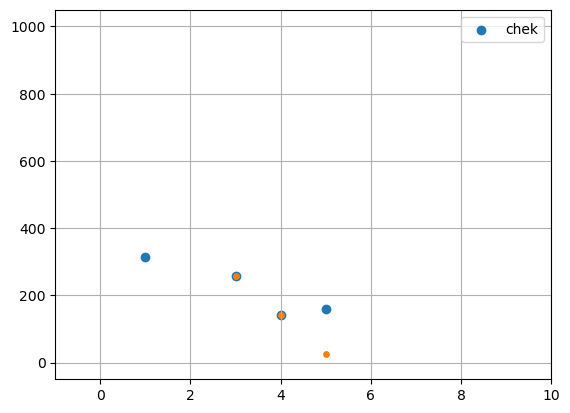

In [6]:
fact_min = 0.26
fact_max = 0.73
ith = 1
#mask = (Xcm[:,ith,0] > Lbox * fact_min) & (Xcm[:,ith,0] < Lbox * fact_max) & \
#       (Xcm[:,ith,1] > Lbox * fact_min) & (Xcm[:,ith,1] < Lbox * fact_max) & \
mask = (Xcm[:,ith,2] > Lbox * fact_min) & (Xcm[:,ith,2] < Lbox * fact_max)
print('pbc',np.sum(mask),mask.shape)
#mask_check = (Xcm_check[:,ith,0] > Lbox * fact_min) & (Xcm_check[:,ith,0] < Lbox * fact_max) & \
#             (Xcm_check[:,ith,1] > Lbox * fact_min) & (Xcm_check[:,ith,1] < Lbox * fact_max) & \
mask_check =              (Xcm_check[:,ith,2] > Lbox * fact_min) & (Xcm_check[:,ith,2] < Lbox * fact_max)
print('check',np.sum(mask_check),mask_check.shape)

#plt.scatter(void_selected_check[mask_check],(Vol_interp_check[mask_check,0] * 4/ 3/np.pi)**(1/3))
#plt.scatter(void_selected[mask],(Vol_interp[mask,0] * 4/ 3/np.pi)**(1/3))

plt.scatter(void_selected_check[mask_check],Xcm_check[mask_check,ith,0],label='chek')
plt.scatter(void_selected[mask],Xcm[mask,ith,0],s=15)
print(Xcm[mask,ith,:][:10,:])
#print(Xcm_check[mask_check,ith,:][:10,:])
#print(Xcm_check[mask_check,ith,:][:10,:])
print(np.min(Vol_interp_check[mask_check,ith] * 4/ 3/np.pi)**(1/3))
print(np.min(Vol_interp[mask,ith] * 4/ 3/np.pi)**(1/3))
Rsel_check = (Vol_interp_check[mask_check,ith] * 4/ 3/np.pi)**(1/3)
Rsel = (Vol_interp[mask,ith] * 4/ 3/np.pi)**(1/3)
plt.grid()
plt.legend()
plt.xlim(-1,10)

print(Xcm[5,ith,:])
print(Xcm_check[5,ith,:])

[ 26.65348266 704.05425006 719.70038038]
[160.97603069 704.05425006 719.70038038]


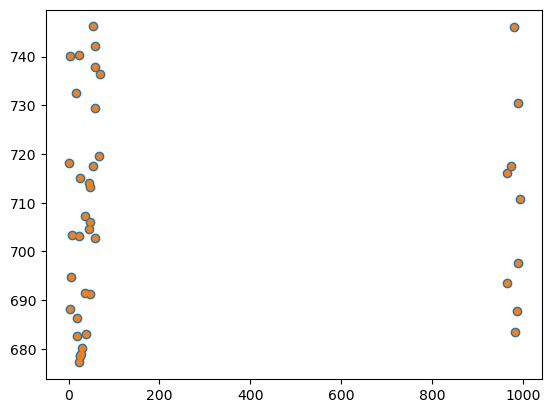

In [7]:
print(Xcm[5,ith,:])
print(Xcm_check[5,ith,:])

plt.scatter(VoroXYZ[ID_voro_dict[5][:int(Ncells_in_void[5,ith])+1],0],VoroXYZ[ID_voro_dict[5][:int(Ncells_in_void[5,ith])+1],1])
plt.scatter(VoroXYZ[ID_voro_dict_check[5][:int(Ncells_in_void_check[5,ith])+1],0],VoroXYZ[ID_voro_dict_check[5][:int(Ncells_in_void_check[5,ith])+1],1],s=15)

[]

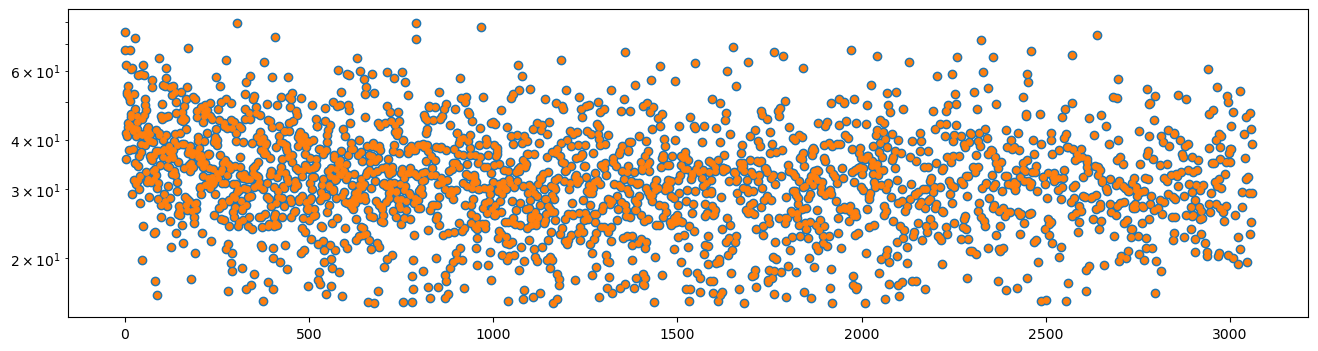

In [8]:
Rall_check = (Vol_interp_check[:,ith] * 4/ 3/np.pi)**(1/3)
Rall = (Vol_interp[:,ith] * 4/ 3/np.pi)**(1/3)
fig = plt.figure(figsize=(16,4))
plt.scatter(void_selected_check,Rall_check,label='check')
plt.scatter(void_selected,Rall,s=15)
plt.semilogy()

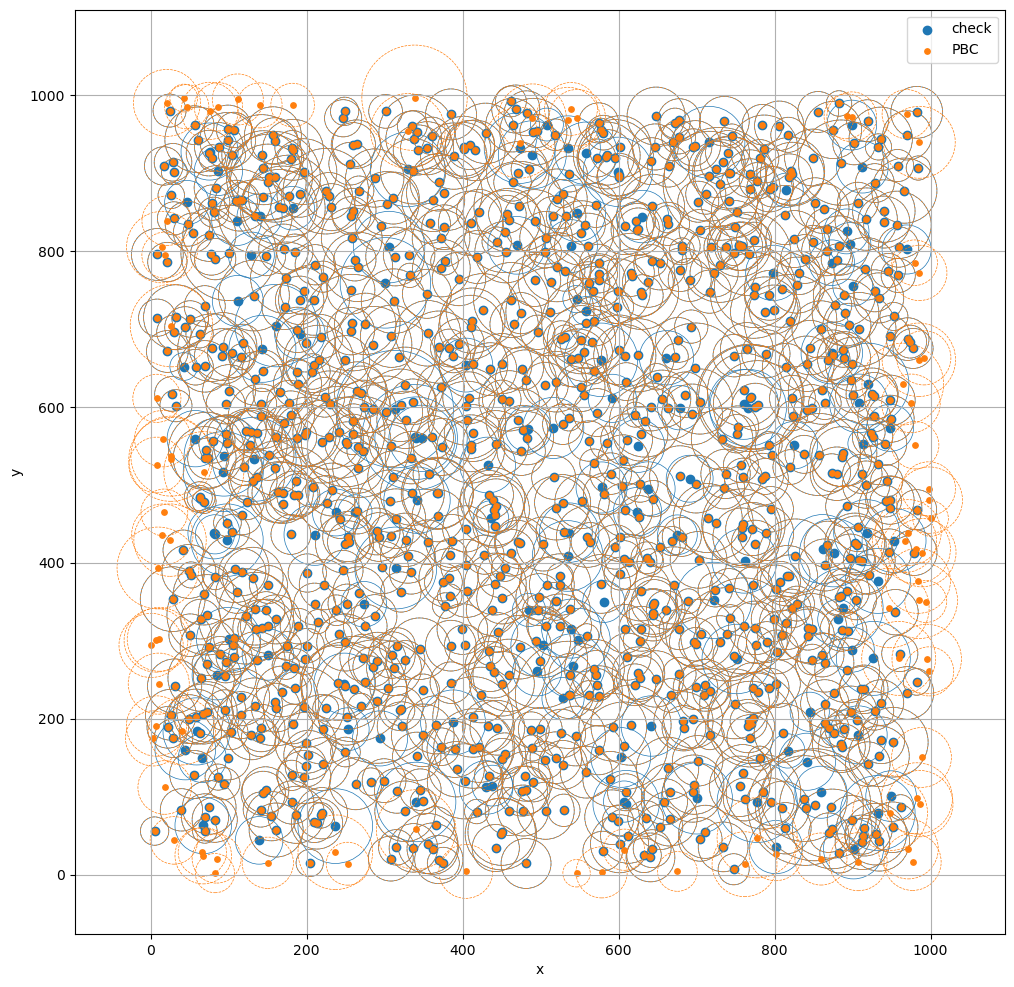

In [9]:
import matplotlib
fig = plt.figure(figsize=(12,12))
ax0 = plt.subplot2grid((1,1), (0,0), rowspan=1, colspan=1)
#ax0 = plt.subplot2grid((1,2), (0,1), rowspan=1, colspan=1)
#ax1 = plt.subplot2grid((1,2), (0,0), rowspan=1, colspan=1)


#RAcm[RAcm<0] +=180
patches = []
CC = []
for i in range(np.sum(mask_check)):
    # circle centered in #RAcm[i],DECcm[i] with radius dist_ang_max[i] * 180 / np.pi
    patches.append(plt.Circle((Xcm_check[mask_check,ith,0][i],Xcm_check[mask_check,ith,1][i]), Rsel_check[i]))
    CC.append(plt.cm.tab10(0))
coll = matplotlib.collections.PatchCollection(patches,facecolors='None',linewidth=0.5,edgecolor=CC)
ax0.scatter(Xcm_check[mask_check,ith,0],Xcm_check[mask_check,ith,1],label='check')
ax0.add_collection(coll)
patches = []
CC = []
for i in range(np.sum(mask)):
    # circle centered in #RAcm[i],DECcm[i] with radius dist_ang_max[i] * 180 / np.pi
    patches.append(plt.Circle((Xcm[mask,ith,0][i],Xcm[mask,ith,1][i]), Rsel[i]))
    CC.append(plt.cm.tab10(1))
coll = matplotlib.collections.PatchCollection(patches,facecolors='None',linestyle='--',linewidth=0.5,edgecolor=CC)
ax0.scatter(Xcm[mask,ith,0],Xcm[mask,ith,1],s=15,label='PBC')
ax0.add_collection(coll)
ax0.axis('equal')
ax0.set_xlabel('x')
ax0.set_ylabel('y')
ax0.grid()
plt.legend()

In [13]:
ids_selected = dict()
for ith in range(len(thresholds)):
    ids_selected[ith] = np.arange(Ncells_in_void.shape[0])[Ncells_in_void[:,ith] > 1.]
    print(ith,Ncells_in_void.shape[0],ids_selected[ith].shape)

0 2219 (1053,)
1 2219 (2219,)


In [14]:
from vorothreshold.overlaps import overlapping_fraction
ids_ovlp, Vol_ovlp, Vol_ovlp_frac, num_ovlps = overlapping_fraction(
    Xcm[:,ith,:], Vol_interp[:,ith], Ncells_in_void[:,ith], VoroXYZ, VoroVol, ID_voro_dict,
    Lbox=Lbox,lightcone=False,id_selected=ids_selected[ith],nthreads=-1,verbose=True)


overlapping_fraction started.

    nthreads set to 32

    R_max computed. Max val = 124.35494621624748

    ngrid not passed. Set to optimal value: 8

    order_ids_tracers_selected_in_voxels started
    done, 0 h 0 min 0.00014328956604003906 sec.

    computation started (periodic-boundaries condition on)
    done, 0 h 0 min 0.008239507675170898 sec. 



In [15]:

ids_ovlp_check, Vol_ovlp_check, Vol_ovlp_frac_check, num_ovlps_check = overlapping_fraction(
    Xcm[:,ith,:], Vol_interp[:,ith], Ncells_in_void[:,ith], VoroXYZ, VoroVol, ID_voro_dict,
    Lbox=Lbox,lightcone=True,id_selected=ids_selected[ith],nthreads=-1,verbose=True)


overlapping_fraction started.

    nthreads set to 32

    R_max computed. Max val = 1394.392340394807

    Lbox passed but lightcone = True: Lbox will be ignored.
    min(xyz_vds) = -0.018104007745404008 0.14335761135709518 0.19740422311336206
    max(xyz_vds) = 1000.0674437109824 999.7592757351346 999.3693271263129
    Lbox = 1000.0855477187278

    ngrid not passed. Set to optimal value: 3

    order_ids_tracers_selected_in_voxels started
    done, 0 h 0 min 0.00015115737915039062 sec.

    computation started (periodic-boundaries condition off)
    done, 0 h 0 min 0.15913128852844238 sec. 



In [16]:
print(np.all(num_ovlps == num_ovlps_check))
print(np.sum(num_ovlps == num_ovlps_check),num_ovlps.shape)
print(num_ovlps[num_ovlps != num_ovlps_check])
print(num_ovlps_check[num_ovlps != num_ovlps_check])

from vorothreshold.overlaps import compute_max_dist2, compute_max_dist2_pbc
R_max = compute_max_dist2_pbc(Ncells_in_void[:,ith],Xcm[:,ith,:],VoroXYZ,ids_selected[ith],ID_voro_dict,Lbox)**0.5
R_max_check = compute_max_dist2(Ncells_in_void[:,ith],Xcm[:,ith,:],VoroXYZ,ids_selected[ith],ID_voro_dict)**0.5

print(R_max[num_ovlps != num_ovlps_check])
print(R_max_check[num_ovlps != num_ovlps_check])

fig = plt.figure(figsize=(12,4))
plt.scatter(np.arange(np.sum(num_ovlps != num_ovlps_check)),num_ovlps[num_ovlps != num_ovlps_check]-num_ovlps_check[num_ovlps != num_ovlps_check],
            c=(R_max_check[num_ovlps != num_ovlps_check]>R_max[num_ovlps != num_ovlps_check]).astype(np.int_),cmap='tab10',vmax=10)
print(np.sum(R_max_check>R_max))

True
2219 (2219,)
[]
[]
[]
[]
297
Error in callback <function _draw_all_if_interactive at 0x14faec0985e0> (for post_execute):


TypeError: '<' not supported between instances of 'float' and 'NoneType'

TypeError: '<' not supported between instances of 'float' and 'NoneType'

<Figure size 1200x400 with 1 Axes>

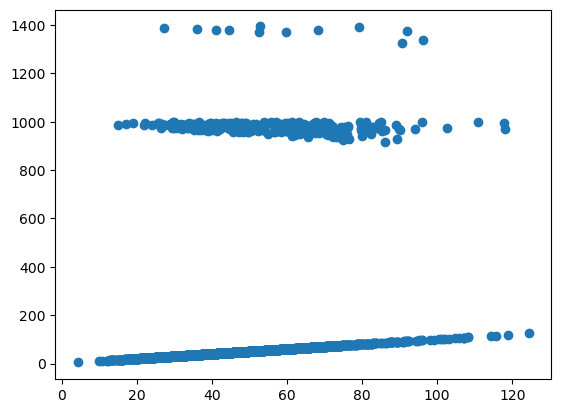

: 

In [16]:
plt.scatter(R_max,R_max_check)
#plt.ylim(0,150)

12 (2219, 395)
[[1142 1011 1334 1836]
 [2098    0    0    0]
 [1409 1415  459    0]
 [1515   34    0    0]
 [ 932 2023  946    0]
 [1903    0    0    0]
 [1435    0    0    0]
 [ 324  763 2206    8]
 [1649    0    0    0]
 [ 636 2115 1998    0]
 [2088 2035    0    0]
 [ 681 1334    0    0]]
[[1142 1011 1334 1832 2196]
 [1898 2196    0    0    0]
 [1409 1781 1415 2196    0]
 [2028 1515 2196    0    0]
 [ 932 2023  575 2182    0]
 [ 534 2182    0    0    0]
 [ 663 2196    0    0    0]
 [   8  324  763 2206  585]
 [1397 2024    0    0    0]
 [2062  636 2115 2182    0]
 [2088 1484 2182    0    0]
 [ 681 1775 2196    0    0]]


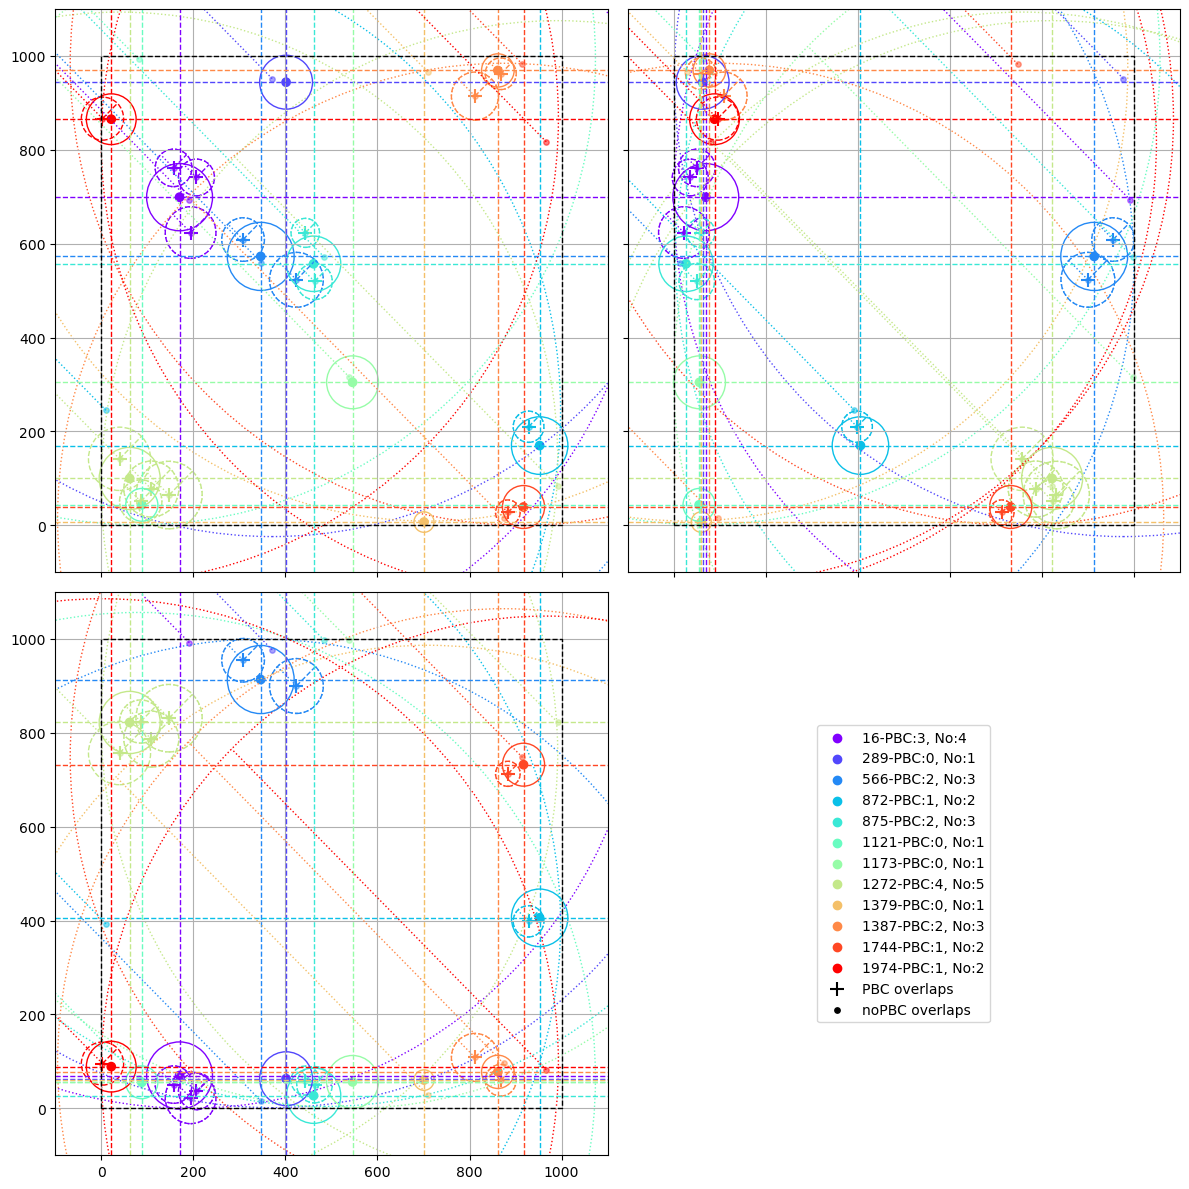

: 

In [20]:
mask_select = (num_ovlps != num_ovlps_check) & (R_max_check == R_max)
print(np.sum(mask_select),ids_ovlp.shape)
#ids_ovlp_check, Vol_ovlp_check, Vol_ovlp_frac_check, num_ovlps_check

print(ids_ovlp[mask_select,:np.max(num_ovlps[mask_select])])
print(ids_ovlp_check[mask_select,:np.max(num_ovlps_check[mask_select])])


x_axis = [0,2,0]
y_axis = [1,1,2]
iii = 0
ax=dict()
fig = plt.figure(figsize=(12,12))
for ijk in range(3):
    ax[ijk] = plt.subplot2grid((2,2), (ijk//2,ijk%2), rowspan=1, colspan=1)
    
    ax[ijk].scatter(Xcm[mask_select,ith,x_axis[ijk]],Xcm[mask_select,ith,y_axis[ijk]],c=np.arange(np.sum(mask_select)),cmap='rainbow')
    patches = []
    CC = []
    for iii in range(np.sum(mask_select)):
        cc = plt.cm.rainbow(iii/(np.sum(mask_select)-1))
        ax[ijk].axvline(Xcm[mask_select,ith,x_axis[ijk]][iii],c=cc,ls='--',lw=1)
        ax[ijk].axhline(Xcm[mask_select,ith,y_axis[ijk]][iii],c=cc,ls='--',lw=1)
        patches.append(plt.Circle((Xcm[mask_select,ith,x_axis[ijk]][iii],Xcm[mask_select,ith,y_axis[ijk]][iii]), R_max[mask_select][iii]))
        CC.append(cc)
        ids_loop = ids_ovlp[mask_select,:num_ovlps[mask_select][iii]][iii]
        patches_loop = []
        ls_loop = []
        CC_loop = []
        ax[ijk].scatter(Xcm[ids_loop,ith,x_axis[ijk]],Xcm[ids_loop,ith,y_axis[ijk]],alpha=1,s=100,color=cc,marker='+')
        for ii in ids_loop:
            patches_loop.append(plt.Circle((Xcm[ii,ith,x_axis[ijk]],Xcm[ii,ith,y_axis[ijk]]), R_max[ii]))
            plt.plot([Xcm[ii,ith,x_axis[ijk]],Xcm[ii,ith,x_axis[ijk]] + 2**-0.5*R_max[ii]],[Xcm[ii,ith,y_axis[ijk]],Xcm[ii,ith,y_axis[ijk]] + 2**-0.5*R_max[ii]],ls='--',lw=1,c=cc)
            CC_loop.append(cc)
            ls_loop.append('--')
        ids_loop = ids_ovlp_check[mask_select,:num_ovlps_check[mask_select][iii]][iii]
        for ii in ids_loop:
            patches_loop.append(plt.Circle((Xcm[ii,ith,x_axis[ijk]],Xcm[ii,ith,y_axis[ijk]]), R_max_check[ii]))
            plt.plot([Xcm[ii,ith,x_axis[ijk]],Xcm[ii,ith,x_axis[ijk]] - 2**-0.5*R_max_check[ii]],[Xcm[ii,ith,y_axis[ijk]],Xcm[ii,ith,y_axis[ijk]] + 2**-0.5*R_max_check[ii]],ls=':',lw=1,c=cc)
            CC_loop.append(cc)
            ls_loop.append(':')
        ax[ijk].scatter(Xcm[ids_loop,ith,x_axis[ijk]],Xcm[ids_loop,ith,y_axis[ijk]],s=15,color=cc,alpha=0.5)
        coll = matplotlib.collections.PatchCollection(patches_loop,facecolors='None',edgecolor=CC_loop,linestyle=ls_loop)
        ax[ijk].add_collection(coll)
    coll = matplotlib.collections.PatchCollection(patches,facecolors='None',edgecolor=CC)
    ax[ijk].add_collection(coll)
    ax[ijk].plot([0,Lbox,Lbox,0,0],[0,0,Lbox,Lbox,0],c='k',lw=1,ls='--')
    ax[ijk].grid()
    if ijk//2 == 0:
        ax[ijk].xaxis.set_major_formatter(plt.NullFormatter())
    if ijk%2 > 0:
        ax[ijk].yaxis.set_major_formatter(plt.NullFormatter())
    ax[ijk].set_xlim(-Lbox/10,Lbox*1.1)
    ax[ijk].set_ylim(-Lbox/10,Lbox*1.1)
ijk = 3
ax[ijk] = plt.subplot2grid((2,2), (ijk//2,ijk%2), rowspan=1, colspan=1)
id_Vds = np.arange(mask_select.shape[0])[mask_select]
for iii in range(np.sum(mask_select)):
    cc = plt.cm.rainbow(iii/(np.sum(mask_select)-1))

    ax[ijk].scatter([],[],color=cc,label=str(id_Vds[iii])+'-PBC:'+str(num_ovlps[mask_select][iii])+', No:'+str(num_ovlps_check[mask_select][iii]))
ax[ijk].scatter([],[],color='k',label='PBC overlaps',s=100,marker='+')
ax[ijk].scatter([],[],color='k',label='noPBC overlaps',s=15)
ax[ijk].legend(loc='center')
ax[ijk].axis('off')  
fig.tight_layout()

12 (2219, 395)
[[1142 1011 1334 1836]
 [2098    0    0    0]
 [1409 1415  459    0]
 [1515   34    0    0]
 [ 932 2023  946    0]
 [1903    0    0    0]
 [1435    0    0    0]
 [ 324  763 2206    8]
 [1649    0    0    0]
 [ 636 2115 1998    0]
 [2088 2035    0    0]
 [ 681 1334    0    0]]
[[1142 1011 1334 1832 2196]
 [1898 2196    0    0    0]
 [1409 1781 1415 2196    0]
 [2028 1515 2196    0    0]
 [ 932 2023  575 2182    0]
 [ 534 2182    0    0    0]
 [ 663 2196    0    0    0]
 [   8  324  763 2206  585]
 [1397 2024    0    0    0]
 [2062  636 2115 2182    0]
 [2088 1484 2182    0    0]
 [ 681 1775 2196    0    0]]


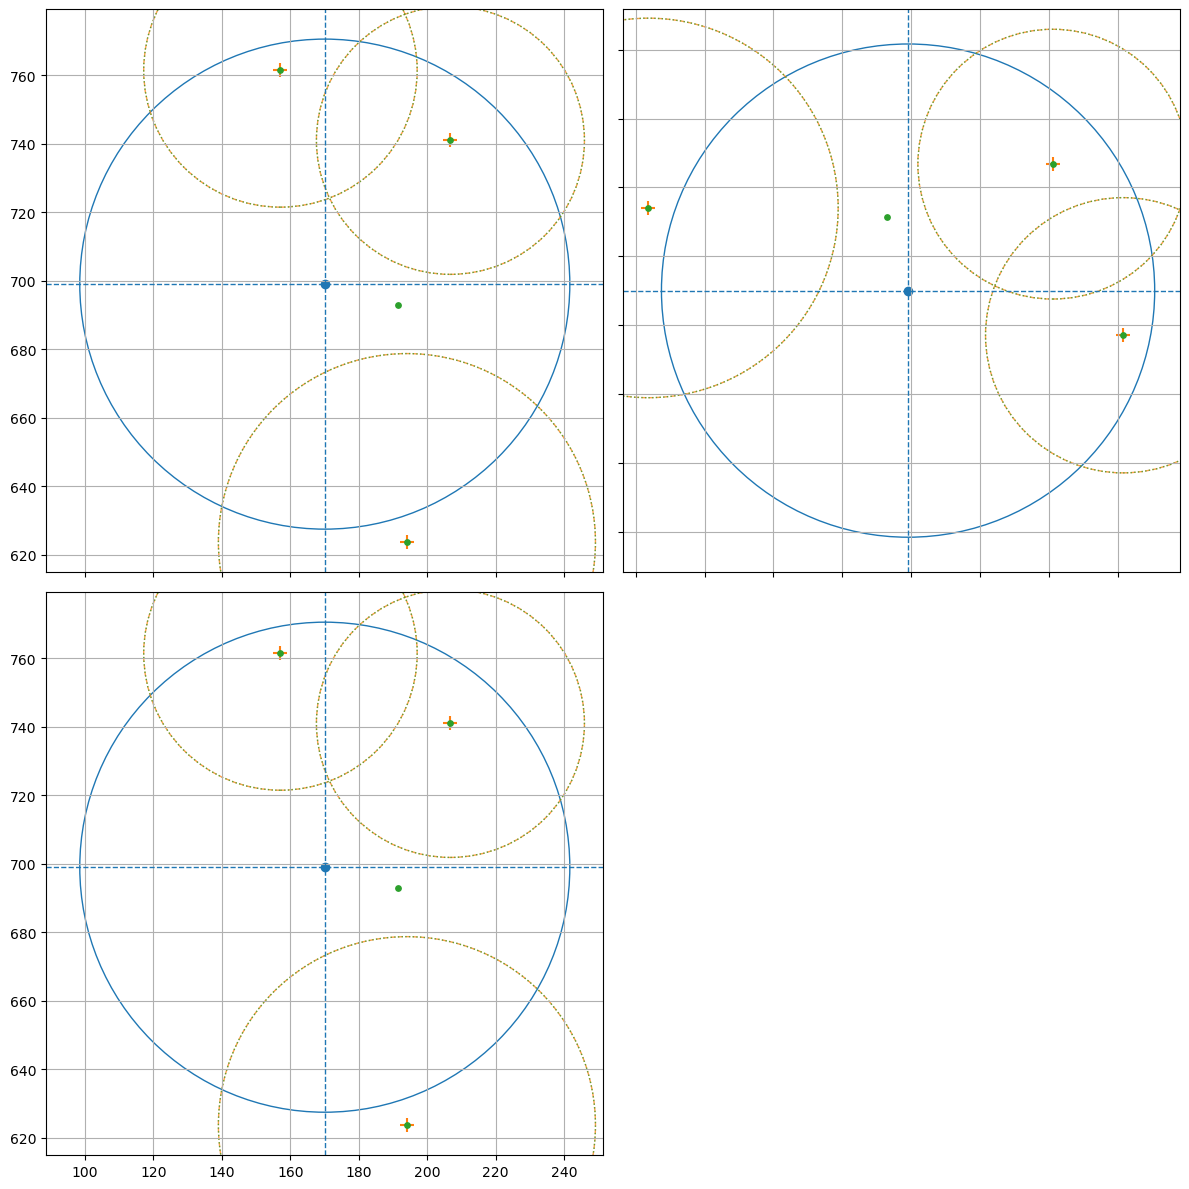

: 

: 

In [94]:
mask_select = (num_ovlps != num_ovlps_check) & (R_max_check == R_max)
print(np.sum(mask_select),ids_ovlp.shape)
#ids_ovlp_check, Vol_ovlp_check, Vol_ovlp_frac_check, num_ovlps_check

print(ids_ovlp[mask_select,:np.max(num_ovlps[mask_select])])
print(ids_ovlp_check[mask_select,:np.max(num_ovlps_check[mask_select])])


iii = 0
ax=dict()
fig = plt.figure(figsize=(12,12))
for ijk in range(3):
    ax[ijk] = plt.subplot2grid((2,2), (ijk//2,ijk%3), rowspan=1, colspan=1)
    

    cc = plt.cm.tab10(0)
    ax[ijk].scatter(Xcm[mask_select,ith,x_axis[ijk]][iii],Xcm[mask_select,ith,y_axis[ijk]][iii],c=cc)
    patches = []
    CC = []
    
    ax[ijk].axvline(Xcm[mask_select,ith,x_axis[ijk]][iii],c=cc,ls='--',lw=1)
    ax[ijk].axhline(Xcm[mask_select,ith,y_axis[ijk]][iii],c=cc,ls='--',lw=1)

    patches.append(plt.Circle((Xcm[mask_select,ith,x_axis[ijk]][iii],Xcm[mask_select,ith,y_axis[ijk]][iii]), R_max[mask_select][iii]))
    CC.append(cc)
    coll = matplotlib.collections.PatchCollection(patches,facecolors='None',edgecolor=CC)
    ax[ijk].add_collection(coll)
    
    ids_loop = ids_ovlp[mask_select,:num_ovlps[mask_select][iii]][iii]
    patches_loop = []
    ls_loop = []
    CC_loop = []
    cc = plt.cm.tab10(1)
    ax[ijk].scatter(Xcm[ids_loop,ith,x_axis[ijk]],Xcm[ids_loop,ith,y_axis[ijk]],alpha=1,marker='+',color=cc,s=100) #,c=cc)
    for ii in ids_loop:
        patches_loop.append(plt.Circle((Xcm[ii,ith,x_axis[ijk]],Xcm[ii,ith,y_axis[ijk]]), R_max[ii]))
        CC_loop.append(cc)
        ls_loop.append('--')
    
    cc = plt.cm.tab10(2)
    ids_loop = ids_ovlp_check[mask_select,:num_ovlps_check[mask_select][iii]][iii]
    for ii in ids_loop:
        patches_loop.append(plt.Circle((Xcm[ii,ith,x_axis[ijk]],Xcm[ii,ith,y_axis[ijk]]), R_max_check[ii]))
        CC_loop.append(cc)
        ls_loop.append(':')
        
    ax[ijk].scatter(Xcm[ids_loop,ith,x_axis[ijk]],Xcm[ids_loop,ith,y_axis[ijk]],s=15,color=cc)
    coll = matplotlib.collections.PatchCollection(patches_loop,facecolors='None',alpha=0.75,edgecolor=CC_loop,linestyle=ls_loop)
    ax[ijk].add_collection(coll)
    if ijk//2 == 0:
        ax[ijk].xaxis.set_major_formatter(plt.NullFormatter())
    if ijk%3 > 0:
        ax[ijk].yaxis.set_major_formatter(plt.NullFormatter())
    
    xlim = ax[ijk].set_xlim()    
    ylim = ax[ijk].set_ylim()
    ax[ijk].plot([0,Lbox,Lbox,0,0],[0,0,Lbox,Lbox,0],c='k',lw=1,ls='--')
    ax[ijk].grid()
    ax[ijk].axis('equal')
    ax[ijk].set_xlim(*xlim)
    ax[ijk].set_ylim(*ylim)
fig.tight_layout()

0.0003921810008910265
0.0009999181
0.00039218209504900744


(array([   45.,  2719., 10060., 16040., 18864., 19907., 19518., 18738.,
        17540., 16383., 14873., 13776., 13045., 11854., 10951., 10214.,
         9107.,  8633.,  8003.,  7465.,  7098.,  6419.,  6187.,  5541.,
         5337.,  4801.,  4691.,  4461.,  4211.,  3850.,  3655.,  3422.,
         3223.,  3095.,  2865.,  2756.,  2620.,  2470.,  2381.,  2223.,
         2166.,  2049.,  2012.,  1877.,  1781.,  1727.,  1602.,  1495.,
         1499.,  1363.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. , 1.1, 1.2,
        1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2. , 2.1, 2.2, 2.3, 2.4, 2.5,
        2.6, 2.7, 2.8, 2.9, 3. , 3.1, 3.2, 3.3, 3.4, 3.5, 3.6, 3.7, 3.8,
        3.9, 4. , 4.1, 4.2, 4.3, 4.4, 4.5, 4.6, 4.7, 4.8, 4.9, 5. ]),
 <BarContainer object of 50 artists>)

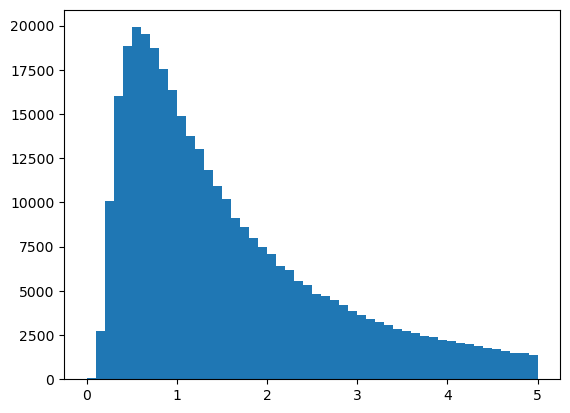

: 

In [17]:
print(VoroVol.shape[0]/Lbox**3)
print(np.mean(1./VoroVol))
print(1./np.mean(VoroVol))
plt.hist(Lbox**3/VoroVol.shape[0]/VoroVol,bins=np.linspace(0,5,51))

To compute the number density as a function of the redshift we need the solid angle of the survey. We compute it by loading the `healpy` mask used by VIDE.

WANING: in that specific case the galaxy number density is approximately constant with respect the redshift, in general it should be fitted on interpolated.

The comoving range `comov_range` computed here, will be used in a further step. Its purpose is to avoid have voids touching the borders (voids that have Voronoi cells crossing this boundary after the threshold procedure, will not be considered).

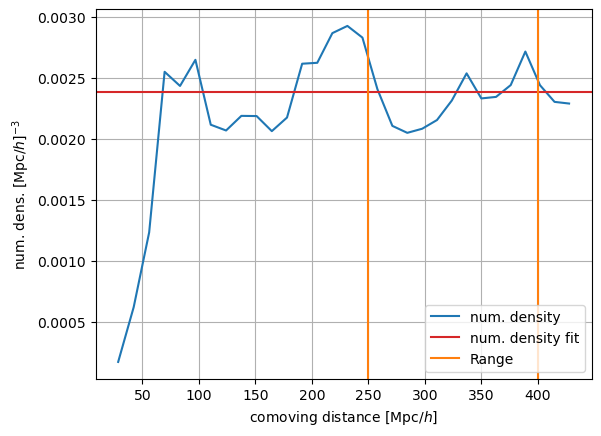

: 

In [4]:
from vorothreshold.utilities import ComovingDistanceOverh
import healpy as hp

mask_gal_file = vide_path + 'mask_map.fits'
mask = hp.read_map(mask_gal_file)
sky_frac = np.sum(mask)/mask.shape[0]

w0=-1.
wa=0.
dist_z = ComovingDistanceOverh(OmegaM,w0,wa)
hist_z, z_bins = np.histogram(redshift,bins=31)

comov_bins = dist_z.get_dist(z_bins)
comov3 = dist_z.get_dist(z_bins)**3
shell_vol = 4*np.pi/3.*sky_frac*(comov3[1:] - comov3[:-1])
z_mean = 0.5 * (z_bins[1:] + z_bins[:-1])
dist_mean = dist_z.get_dist(z_mean)
mean_dens = np.mean((hist_z/shell_vol)[(dist_mean>=75) & (dist_mean<=400)])
comov_range = (250,400)
plt.plot(dist_mean,hist_z/shell_vol,label='num. density')
plt.axhline(mean_dens,label='num. density fit',c=plt.cm.tab10(3))
plt.axvline(comov_range[0],label='Range',c=plt.cm.tab10(1))
plt.axvline(comov_range[1],c=plt.cm.tab10(1))
plt.legend()
plt.ylabel('num. dens. [Mpc/$h$]$^{-3}$')
plt.xlabel('comoving distance [Mpc/$h$]')
plt.grid()

zDens = np.full(redshift.shape[0],mean_dens)

The computation are performed in the initialization of the `voronoi_threshold_finder` class, passing as arguments the ones listed above. The `thresholds` list can contain many values.

To post process vide voids in an automatic way, the mandatory variables are: `thresholds`, `vide_path`, and `tracer_dens`. Other important quantities that will be computed by the code if not passed are: 

- `comov_range` (or `z_range`), which are the distance boundary, voids with Voronoi cells exceeding these value will be discarded;

- `ang_paddig_rad` padding around the border of the healpix mask, voids with Voronoi cells within this padding  will be discarded;

- `OmegaM`, `w0`,`wa` can either be passed or recoverd from the Vide output. The these values differ from the ones from Vide, a warning will be raise.

In [5]:
thresholds = [0.2,0.3]

th_voids = voronoi_threshold_finder(thresholds,lightcone=True,tracer_dens=zDens,vide_path=vide_path,comov_range=comov_range,OmegaM=OmegaM,w0=w0,wa=wa,verbose=True)

    Loading VIDE data.
        done: 0 h 0 min 3.7897286415100098 sec.
    max_num_part < 0: authomatically set to 5 * max(num_part): 3685

    voronoi_threshold started

    nthreads set to 32

    max_num_part set to 3685

    computation started
    done, 0 h 0 min 11.138100862503052 sec. 

        main computation done: 0 h 0 min 11.212455034255981 sec.
    angular and radial mask started.
    angular mask loaded, nside = 128
    ang_paddig_rad = 0.05987692941422614 npadding_ang = 8
        done: 0 h 0 min 7.765408039093018 sec.


: 

In [6]:
max_voro_in_voids = np.max(th_voids.get_values(np.max(thresholds),'Ncells',1.))
max_voro_in_voids = int(max_voro_in_voids) + int(max_voro_in_voids%1 > 0)
print('max_num_part passed:',th_voids.max_num_part,'max num of voronoi in one void:',max_voro_in_voids,
      'Nvds with num max:',np.sum(th_voids.get_values(np.max(thresholds),'Ncells',1.)==max_voro_in_voids))
print(th_voids.Ncells_in_void.shape)
print(th_voids.Vol_interp.shape)
import h5py
with h5py.File('/mnt/home/gverza/ceph/test_box.h5','w') as ff:
      ff.create_dataset('Ncells_in_void',data=th_voids.Ncells_in_void)
      ff.create_dataset('Vol_interp',data=th_voids.Vol_interp)
      ff.create_dataset('Xcm',data=th_voids.Xcm)
      ff.create_dataset('ell_eigenvalues',data=th_voids.ell_eigenvalues)
      ff.create_dataset('ell_eigenvectors',data=th_voids.ell_eigenvectors)
      ff.create_dataset('void_selected',data=th_voids.void_selected)
      for iv in range(th_voids.Ncells_in_void.shape[0]):
            ff.create_dataset('ID_voro_dict/'+str(iv),data=th_voids.ID_voro_dict[iv][:int(th_voids.Ncells_in_void[iv,-1])+1])

print(th_voids.void_selected)

max_num_part passed: 3685 max num of voronoi in one void: 82 Nvds with num max: 0
(214, 2)
(214, 2)
[  0   4   6   8   9  11  12  13  14  15  19  20  21  24  26  27  28  29
  30  31  32  35  36  38  39  42  43  46  47  49  50  52  53  54  57  62
  63  65  66  69  70  71  73  76  77  78  82  83  84  88  92  93  94  95
  96  97  98 101 102 104 105 107 109 111 114 116 117 120 123 125 126 128
 130 133 134 136 137 144 149 151 155 157 161 162 163 164 165 167 168 169
 170 172 173 176 178 180 181 182 183 187 190 192 194 196 198 202 204 206
 207 208 210 214 215 216 218 220 221 224 225 226 227 228 229 232 234 237
 238 240 243 246 247 248 255 257 259 260 261 263 266 269 270 272 273 274
 275 277 280 285 287 289 292 294 295 300 304 306 311 312 314 315 316 318
 320 323 325 326 331 332 336 339 345 346 347 351 353 362 365 367 368 370
 372 373 376 382 385 386 388 392 393 395 399 401 402 403 404 405 406 410
 412 415 416 422 424 425 426 427 430 432 433 437 438 439 443 448]


: 

To get threshold void properties, we use the `get_values` function from the `voronoi_threshold_finder` class. The arguments are the specific threshold value, among the values in `thresholds`, the quantity we want to obtain, and the overlapping fraction,`frac_ovlp`. This last quantity represents the maximum fractional amount of volume shared with an anther void. It is a free parameter, any value below or equal to 0.5 is fine. The corresponding output will contains voids which overlaps for a fraction of their volume minor or equal to `frac_ovlp`. The use of `frac_ovlp` is necessary to avoid double counting, as the thresholding procedure may merge adjacent basins in a unique void.

The ids of non-overlapping voids for a specific `frac_ovlp` is computed the first time that the value is passed to the `get_values` function. Alternatively, the ids can be computed by calling the `compute_overlaps` function, which accept as arguments both a single `frac_ovlp`, or multiple values passed as a list or a `numpy` array. In such a case, all the computations for all the combination `frac_ovlp` and `thresholds` values will be performed in parallel.

In [7]:
th_voids.compute_overlaps(np.array([0.5,0.25,0.]),verbose=False)

print('keys:',th_voids.id_out.keys())
print('keys:',th_voids.id_out[0].keys())

keys: dict_keys([0, 1])
keys: dict_keys([0.5, 0.25, 0.0])


: 

The following cell extract some threshold voids properties with `get_values`. The list of available options is the following: 


- Ncells: Number of Voronoi cells contained in each void. This is an array of float as the last Voronoi cell adds as the volume fraction considered to reach the threshold value. dtype=float64, shape=(N,)
        
- ID_original_sample: IDs of the void of the original VIDE catalog used to start the thresholding process. dtype=int64, shape=(N,)
            
- id_selected: IDs of voids of the entire voronoi_threshold output that reach the threshold value and satisfying the overlaps condition. dtype=int64, shape=(N,)

- id_wrt_all: IDs of voids of the entire voronoi_threshold output that reach the threshold value and satisfying the overlaps condition. dtype=int64, shape=(N,)

- xyz: Comoving coordinates of the volume weighted barycenter. dtype=float64, shape=(N,3)

- RA: Right ascension of the volume weighted barycenter. dtype=float64, shape=(N,)

- DEC: Declination of the volume weighted barycenter. dtype=float64, shape=(N,)

- comov_dist: Comoving distance of the volume weighted barycenter. dtype=float64, shape=(N,)

- redshift: Redshift of the volume weighted barycenter. dtype=float64, shape=(N,)

- volume: Void volumes. dtype=float64, shape=(N,)

- radius: Void effective radius. dtype=float64, shape=(N,)

- ell_eigenvalues: eigenvalues of the inertial tensor. dtype=float64, shape=(N,3)

- ell_eigenvectors: eigenvectors of the inertial tensor. dtype=float64, shape=(N,3,3)

- angular_mask: healpix mask used to select voids, obtained by padding the original healpix mask with `ang_paddig_rad`. Only voids with all the Voronoi cells included in this mask are selected. The `frac_ovlp` value is not needed


In [8]:
xyz = dict()
radius = dict()
z_voids = dict()
frac_ovlp = 0.5
for thr in thresholds:
    xyz[thr] = dict()
    radius[thr] = dict()
    z_voids[thr] = dict()
    xyz[thr][frac_ovlp] = th_voids.get_values(thr,'xyz',frac_ovlp)
    radius[thr][frac_ovlp] = th_voids.get_values(thr,'radius',frac_ovlp)
    z_voids[thr][frac_ovlp] = th_voids.get_values(thr,'redshift',frac_ovlp)
    #print(xyz[thr][frac_ovlp].shape,radius[thr][frac_ovlp].shape,z_voids[thr][frac_ovlp].shape)

: 

Plot of the spatial distribution of threshold voids. Since the original galaxy sample is small, many threshold voids has Voronoi cells touching borders.

Text(0.5, 0, 'z [Mpc/$h$]')

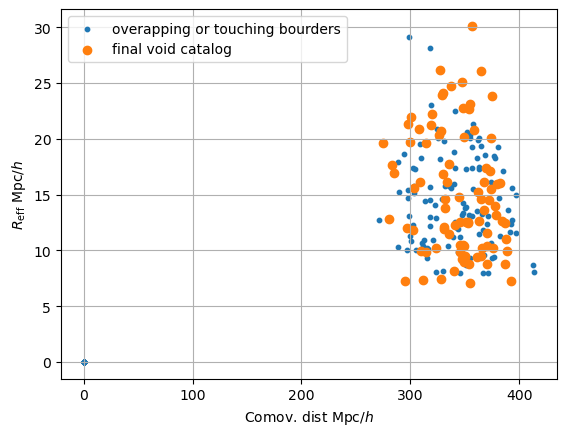

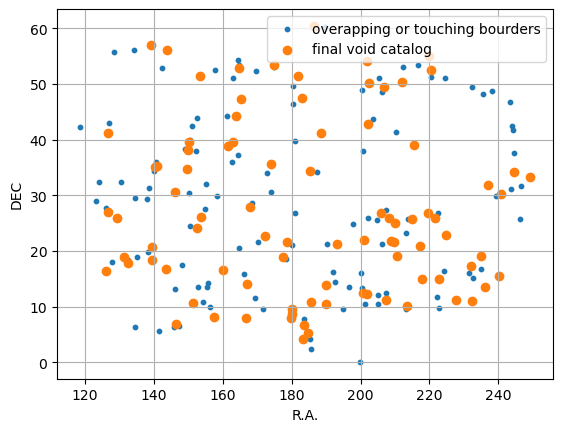

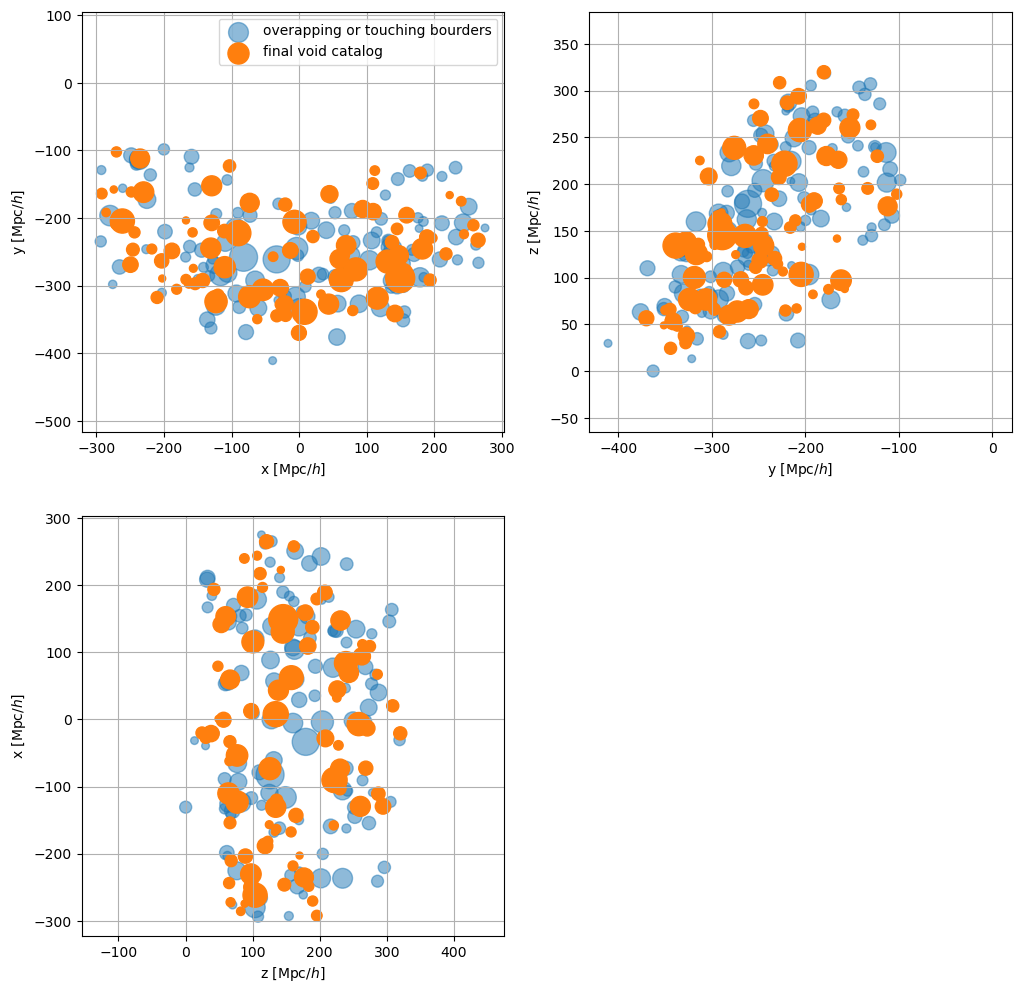

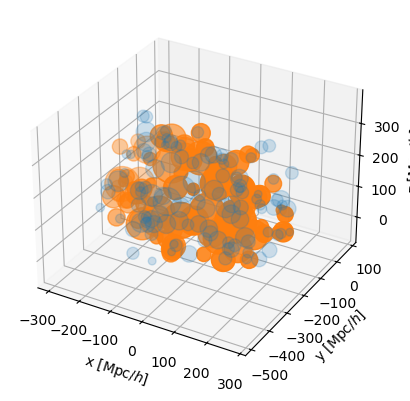

: 

In [9]:
from vorothreshold.utilities import from_XYZ_to_rRAdec
from vorothreshold.read_funcs import vide_voids_cat
thr = 0.3
ith = 0
comov_dist = dict()
RA = dict()
DEC = dict()
volume = dict()
for frac_ovlp in [1.,0.5,0.25,0.1,0.]:
    comov_dist[thr] = dict()
    RA[thr] = dict()
    DEC[thr] = dict()
    volume[thr] = dict()
    
    xyz[thr][frac_ovlp] = th_voids.get_values(thr,'xyz',frac_ovlp)
    radius[thr][frac_ovlp] = th_voids.get_values(thr,'radius',frac_ovlp)
    volume[thr][frac_ovlp] = th_voids.get_values(thr,'volume',frac_ovlp)
    z_voids[thr][frac_ovlp] = th_voids.get_values(thr,'redshift',frac_ovlp)
    RA[thr][frac_ovlp] = th_voids.get_values(thr,'RA',frac_ovlp)
    DEC[thr][frac_ovlp] = th_voids.get_values(thr,'DEC',frac_ovlp)
    comov_dist[thr][frac_ovlp] = np.sum(xyz[thr][frac_ovlp]**2,axis=1)**0.5 #th_voids.get_values(thr,'comov_dist',frac_ovlp)
    #print(frac_ovlp,xyz[thr][frac_ovlp].shape,radius[thr][frac_ovlp].shape,z_voids[thr][frac_ovlp].shape)
dist_all, RA_all, DEC_all = from_XYZ_to_rRAdec(th_voids.Xcm[:,ith,0],th_voids.Xcm[:,ith,1],th_voids.Xcm[:,ith,2])

barycenter,Reff_vide,redshift_vds,voidID,RAvide,DEC_vide,coreID,core_dens,core_pos,RAcore,DECcore,redshift_core = vide_voids_cat(vide_path,'example_observation',
    values_out=['barycenter','radius','redshift','voidID','RA','DEC','core_ID','core_dens','core_pos','RAcore','DECcore','redshift_core'],as_dict=False)
fig = plt.figure()
#plt.scatter(dist_z.get_dist(redshift_vds),Reff_vide)
plt.scatter(dist_all,(th_voids.Vol_interp[:,ith]* 3. / (4. * np.pi)) ** (1./3.),label='overapping or touching bourders',s=10)
plt.scatter(comov_dist[thr][frac_ovlp],radius[thr][frac_ovlp],label='final void catalog')#,s=5)
#plt.axvline(comov_range[0])
#plt.axvline(comov_range[1])
#plt.xlim(250,450)
#print(np.argmax(th_voids.Vol_interp[:,0]),np.max(th_voids.Vol_interp[:,0]))
plt.legend()
plt.grid()
plt.xlabel('Comov. dist Mpc/$h$')
plt.ylabel('$R_{\\rm eff}$ Mpc/$h$')

fig = plt.figure()
plt.scatter(RA_all,DEC_all,label='overapping or touching bourders',s=10)
plt.scatter(RA[thr][frac_ovlp]%360,DEC[thr][frac_ovlp],label='final void catalog')#,s=5)
plt.legend()
plt.grid()
plt.xlabel('R.A.')
plt.ylabel('DEC')
#print(th_voids.Vol_interp.shape,Reff_vide.shape)


fig = plt.figure(figsize=(12,12))
ax = dict()
for i in range(3):
    ax[i] = plt.subplot2grid((2,2), (int(i/2),i%2), rowspan=1, colspan=1)
    ax[i].scatter(th_voids.Xcm[:,ith,i%3],th_voids.Xcm[:,ith,(i+1)%3],s=(th_voids.Vol_interp[:,ith]* 3. / (4. * np.pi)/3) ** (2./3.),alpha=0.5,label='overapping or touching bourders')
    ax[i].scatter(xyz[thr][frac_ovlp][:,i%3],xyz[thr][frac_ovlp][:,(i+1)%3],s=(volume[thr][frac_ovlp]* 3. / (4. * np.pi)/3) ** (2./3.),label='final void catalog')
    ax[i].axis('equal')
    ax[i].grid()
    ax[i].set_xlabel(['x','y','z'][i%3]+' [Mpc/$h$]')
    ax[i].set_ylabel(['x','y','z'][(i+1)%3]+' [Mpc/$h]$')
ax[0].legend()


fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(th_voids.Xcm[:,ith,0],th_voids.Xcm[:,ith,1],th_voids.Xcm[:,ith,2],s=(th_voids.Vol_interp[:,ith]* 3. / (4. * np.pi)/3) ** (2./3.),alpha=0.2)
ax.scatter(xyz[thr][frac_ovlp][:,0],xyz[thr][frac_ovlp][:,1],xyz[thr][frac_ovlp][:,2],s=(radius[thr][frac_ovlp]) ** 2.)
ax.axis('equal')
ax.set_xlabel('x [Mpc/$h$]')
ax.set_ylabel('y [Mpc/$h$]')
ax.set_zlabel('z [Mpc/$h$]')

Plot of the spatial distribution of Voronoi cells belonging to threshold voids with respect to the full galaxy distribution.

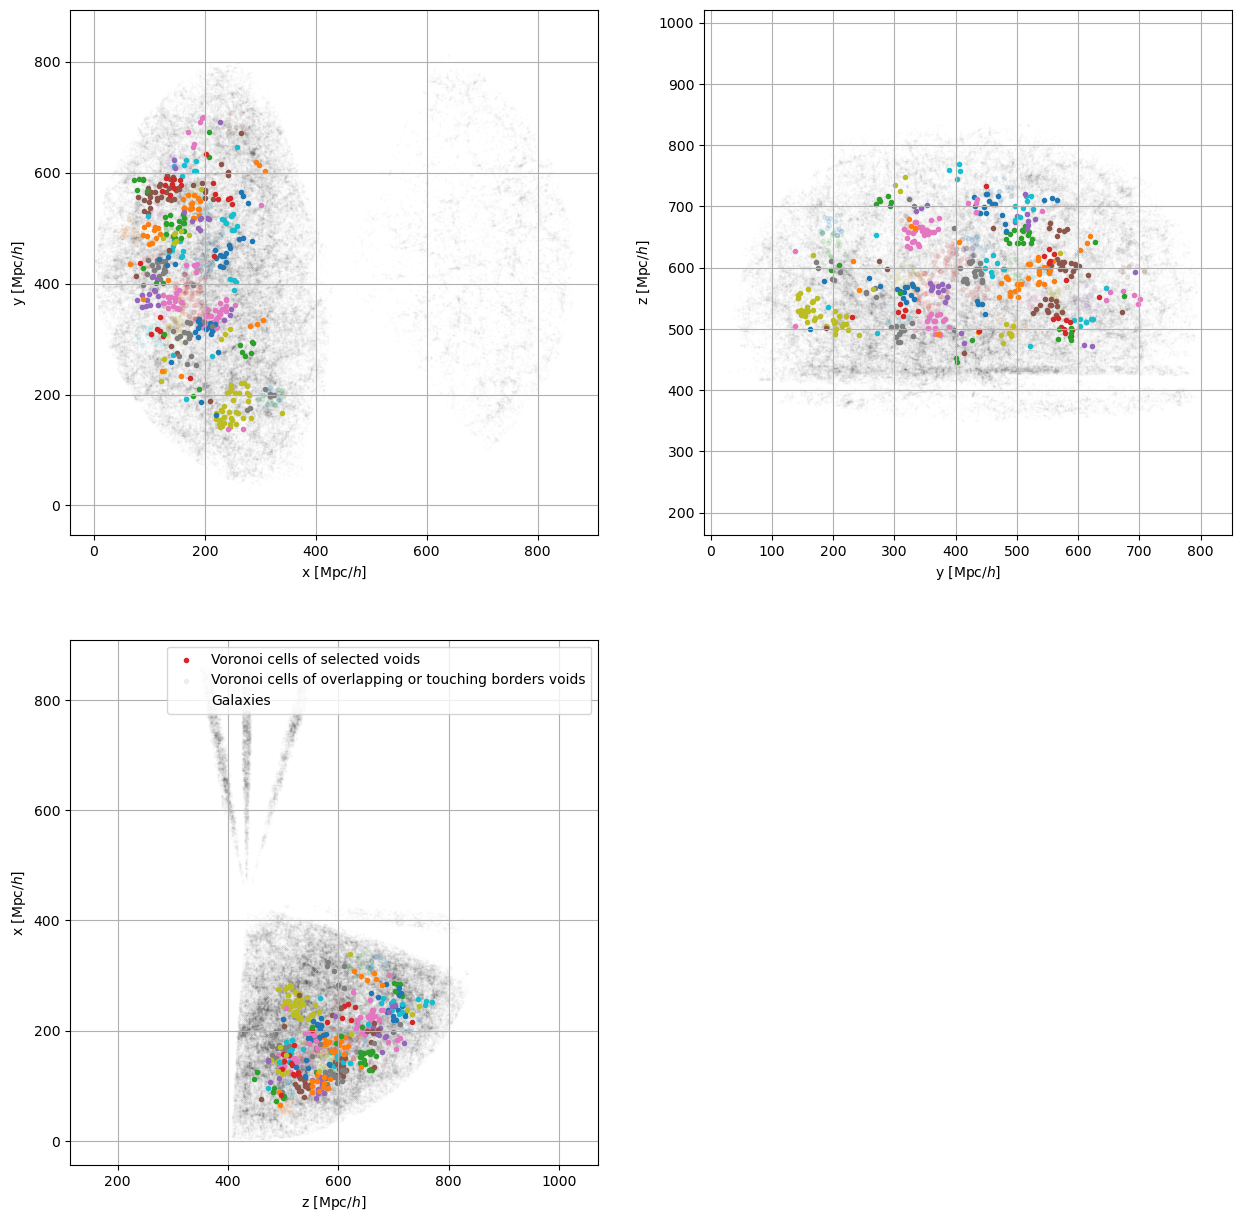

: 

In [10]:
#from vorothreshold.read_funcs import read_voronoi_vide
#asd = voro_in_vide_voids('data/lightcone/examples/example_observation/sample_example_observation/','example_observation')

id_selected = np.arange(th_voids.Xcm.shape[0])[th_voids.Ncells_in_void[:,0] > 10]
id_ovlp_out = th_voids.get_values(thr,'id_selected',frac_ovlp)
fig = plt.figure(figsize=(15,15))
ax = dict()
for i in range(3):
    ax[i] = plt.subplot2grid((2,2), (int(i/2),i%2), rowspan=1, colspan=1)
    ax[i].scatter(VoroXYZ[:,i%3],VoroXYZ[:,(i+1)%3],s=0.1,alpha=0.02,c='k')
progr = 0
for id in id_selected:
    Xcm_interp = th_voids.Xcm[id,ith,:]
    IDthresholds = th_voids.ID_voro_dict[id][:int(th_voids.Ncells_in_void[id,0]+1)]
    alpha = 0.1
    for i in range(3):
        ax[i].scatter(VoroXYZ[IDthresholds,i%3],VoroXYZ[IDthresholds,(i+1)%3],s=9,alpha=0.1)
            #ax[i].scatter(Xcm_interp[i%3],Xcm_interp[(i+1)%3])
        #ax[i].scatter(core_pos[iv,i%3],core_pos[iv,(i+1)%3],c='r',)
        #ax[i].scatter(barycenter[iv,i%3],barycenter[iv,(i+1)%3],c='m')
    progr +=1
progr = 0
for id in id_ovlp_out:
    Xcm_interp = th_voids.Xcm[id,ith,:]
    IDthresholds = th_voids.ID_voro_dict[id][:int(th_voids.Ncells_in_void[id,0]+1)]
    
    for i in range(3):
        ax[i].scatter(VoroXYZ[IDthresholds,i%3],VoroXYZ[IDthresholds,(i+1)%3],s=9,alpha=1.)
            #ax[i].scatter(Xcm_interp[i%3],Xcm_interp[(i+1)%3])
        #ax[i].scatter(core_pos[iv,i%3],core_pos[iv,(i+1)%3],c='r',)
        #ax[i].scatter(barycenter[iv,i%3],barycenter[iv,(i+1)%3],c='m')
    progr +=1
for i in range(3):
    ax[i].axis('equal')
    ax[i].set_xlabel(['x','y','z'][i%3]+' [Mpc/$h$]')
    ax[i].set_ylabel(['x','y','z'][(i+1)%3]+' [Mpc/$h$]')
    ax[i].grid()
ax[2].scatter(np.nan,np.nan,s=9,alpha=1.,label='Voronoi cells of selected voids')
ax[2].scatter(np.nan,np.nan,s=9,alpha=0.1,label='Voronoi cells of overlapping or touching borders voids')
ax[2].scatter(np.nan,np.nan,s=0.1,alpha=0.02,c='k',label='Galaxies')
ax[2].legend()

Get and plot the angular mask used to avoid Voronoi cells touching borders.

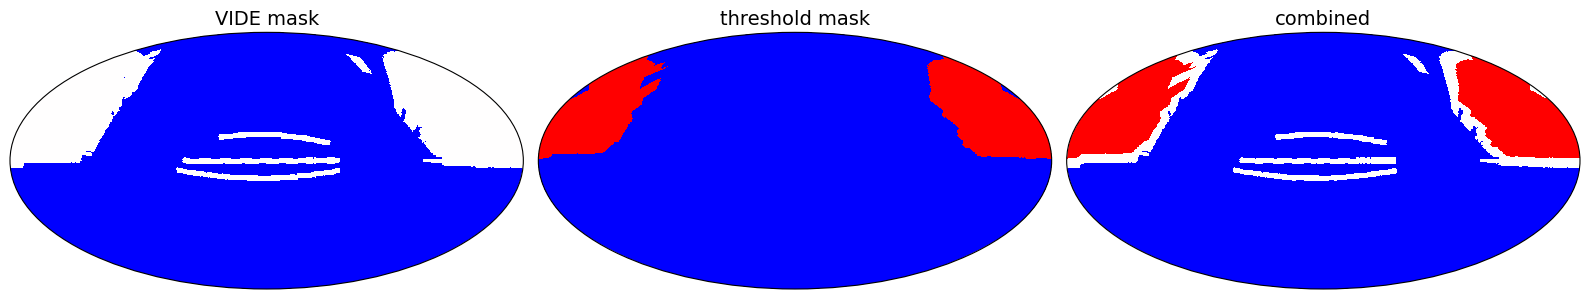

: 

In [11]:
from healpy.newvisufunc import projview

thr_mask = th_voids.get_values(thr,'angular_mask')
vide_mask = hp.read_map(vide_path + '/mask_map.fits')

cmap = 'bwr'
norm=1.
fig = plt.figure(figsize=(16,6))
projview(
    vide_mask*norm,
    title="VIDE mask",
    min=0.,
    max=2.,
    sub=131,
    cbar=False,
    cmap=cmap
);

projview(
    thr_mask*norm,
    title="threshold mask",
    min=0.,
    max=1.,
    sub=132,
    cbar=False,
    cmap=cmap
);

projview(
    (thr_mask + vide_mask)*norm,
    title="combined",
    min=0.,
    max=2.,
    sub=133,
    cbar=False,
    cmap=cmap
);
fig.tight_layout()